In [1]:
from statistics import mode, kde

from pandas.core.computation.expressions import where

"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""

'\nExercise 4: NumPy Array Operations\nComplete the following tasks using NumPy.\n'

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0

# Create matrix
matrix55 = np.zeros((5, 5))

# Now make border items 1
matrix55[:, 0] = 1
matrix55[:, -1] = 1

matrix55

array([[1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.]])

In [3]:
# Task 2: Normalize a random array

# Each col having mean = 0 & std = 1 by default
np.random.seed(42)
randArr = np.random.randn(100, 3)
randArr


array([[ 0.49671415, -0.1382643 ,  0.64768854],
       [ 1.52302986, -0.23415337, -0.23413696],
       [ 1.57921282,  0.76743473, -0.46947439],
       [ 0.54256004, -0.46341769, -0.46572975],
       [ 0.24196227, -1.91328024, -1.72491783],
       [-0.56228753, -1.01283112,  0.31424733],
       [-0.90802408, -1.4123037 ,  1.46564877],
       [-0.2257763 ,  0.0675282 , -1.42474819],
       [-0.54438272,  0.11092259, -1.15099358],
       [ 0.37569802, -0.60063869, -0.29169375],
       [-0.60170661,  1.85227818, -0.01349722],
       [-1.05771093,  0.82254491, -1.22084365],
       [ 0.2088636 , -1.95967012, -1.32818605],
       [ 0.19686124,  0.73846658,  0.17136828],
       [-0.11564828, -0.3011037 , -1.47852199],
       [-0.71984421, -0.46063877,  1.05712223],
       [ 0.34361829, -1.76304016,  0.32408397],
       [-0.38508228, -0.676922  ,  0.61167629],
       [ 1.03099952,  0.93128012, -0.83921752],
       [-0.30921238,  0.33126343,  0.97554513],
       [-0.47917424, -0.18565898, -1.106

In [4]:
# Task 3: Implement linear regression solution using normal equation

X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# Normal eqn (theta = (X^T X)^(-1) X^T y) translated:
theta_hat = np.linalg.inv((np.transpose(X) @ X)) @ (np.transpose(X) @ y)

print(f"True Theta: ", true_theta)
print(f"Theta hat: ", theta_hat)


True Theta:  [ 2.5 -1.2  3.7]
Theta hat:  [ 2.51723721 -1.19783796  3.72399266]


In [5]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

In [6]:
## Task 1: Data Cleaning and Exploration

# Display basic information about the dataset
df.describe()


# Identify and count missing values
missingValsCount = df.isnull().sum().sum()
print(f"Total missing values in data frame: ", missingValsCount)


# Fill missing exam_score with the mean score for the student's major
df_stats = df.groupby('major')['exam_score'].agg(['mean'])

for index, row in df[df['exam_score'].isnull()].iterrows():
    major = row['major']
    mean_for_major = df_stats.loc[major, 'mean']
    df.loc[index, 'exam_score'] = mean_for_major


# Fill missing hours_studied with the median for the student's year
df_stats2 = df.groupby('year')['hours_studied'].agg(['median'])
df_nulls2 = df[df['hours_studied'].isnull()]


for index, row in df[df['hours_studied'].isnull()].iterrows():
    year = row['year']
    median_for_year = df_stats2.loc[year, 'median']
    df.loc[index, 'hours_studied'] = median_for_year


Total missing values in data frame:  15


In [7]:
## Task 2: Analysis

# Calculate and display the average exam_score by major
avg_score_by_major = df.groupby('major')['exam_score'].agg(['mean'])
avg_score_by_major.head()


# Find the major with the highest average exam_score
avg_score_by_major.sort_values('mean', ascending=False).head(1)


# Calculate the correlation between hours_studied and exam_score
df_correlation = df['exam_score'].corr(df['hours_studied'])
print(f"Correlation b/n exam scores and hours studied is: ", df_correlation)


# Create new 'performance' column
# 'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
df['Performance'] = np.where(df['exam_score'] > 90, 'Excellent',
                    np.where((df['exam_score'] >= 80) & (df['exam_score'] < 90), 'Good',
                    np.where((df['exam_score'] >= 70) & (df['exam_score'] < 80), 'Average', 'Needs Improvement')))

Correlation b/n exam scores and hours studied is:  -0.055981383472924445


In [8]:
# Task 3: Advanced Analysis

# Task 3: Advanced Analysis (10 points)
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied

df.groupby(['major', 'year']).agg({ 'exam_score': ['mean'], 'hours_studied': ['mean'], 'student_id': ['count'] })


# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
df['Rank'] = df['exam_score'].rank(method='dense', ascending=False)
leaderboard = df[df['Rank'] <= 5].sort_values(by='Rank')


# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)
table = pd.pivot_table(df, values='exam_score', index=['major'], columns=['year'], aggfunc='mean')




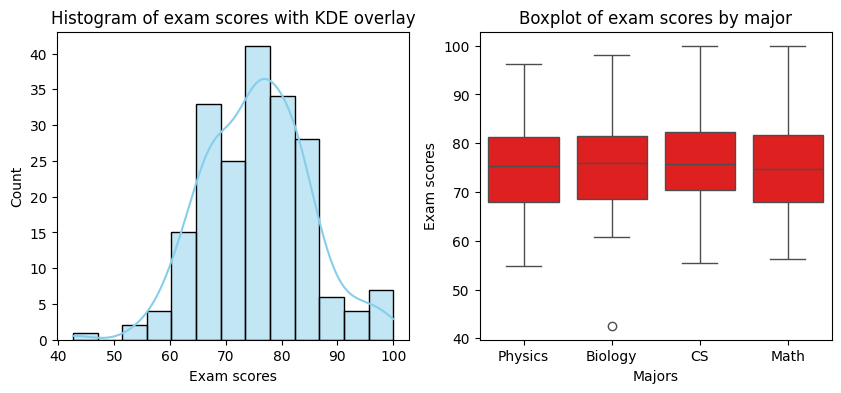

In [31]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""


# Task 1: Distribution Visualization (8 points)
# TODO: Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
# TODO: Add appropriate titles, labels, and styling


fig, plots = plt.subplots(1, 2, figsize=(10, 4))


sns.histplot(
    df['exam_score'],
    kde=True,
    ax=plots[0],
    color="skyblue",
    stat="count",
)

sns.boxplot(
    df,
    x='major',
    y='exam_score',
    ax=plots[1],
    color="red",
)

plots[0].set_xlabel("Exam scores")


plots[1].set_ylabel("Exam scores")
plots[1].set_xlabel("Majors")

plots[0].set_title('Histogram of exam scores with KDE overlay')
plots[1].set_title('Boxplot of exam scores by major')

plt.show()

Text(0, 0.5, 'Exam scores')

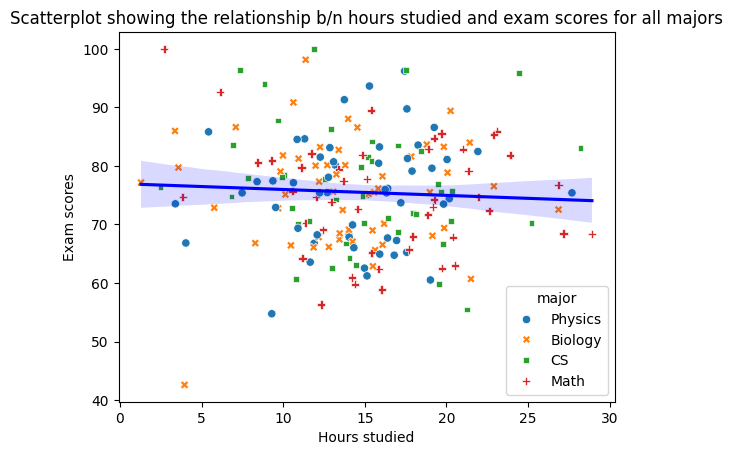

In [43]:
# Task 2: Relationship Visualization (8 points)
# TODO: Create a scatter plot of hours_studied vs exam_score
# TODO: Color points by major
# TODO: Add a regression line
# TODO: Include appropriate legends, titles, and axis labels

k = sns.scatterplot(df, x='hours_studied', y='exam_score', hue='major', style='major')

sns.regplot(df, x='hours_studied', y='exam_score', scatter=False, ax = k, color='blue')

k.set_title('Scatterplot showing the relationship b/n hours studied and exam scores for all majors')
k.set_xlabel('Hours studied')
k.set_ylabel('Exam scores')

Text(1332.0404040404037, 0.5, 'Performance')

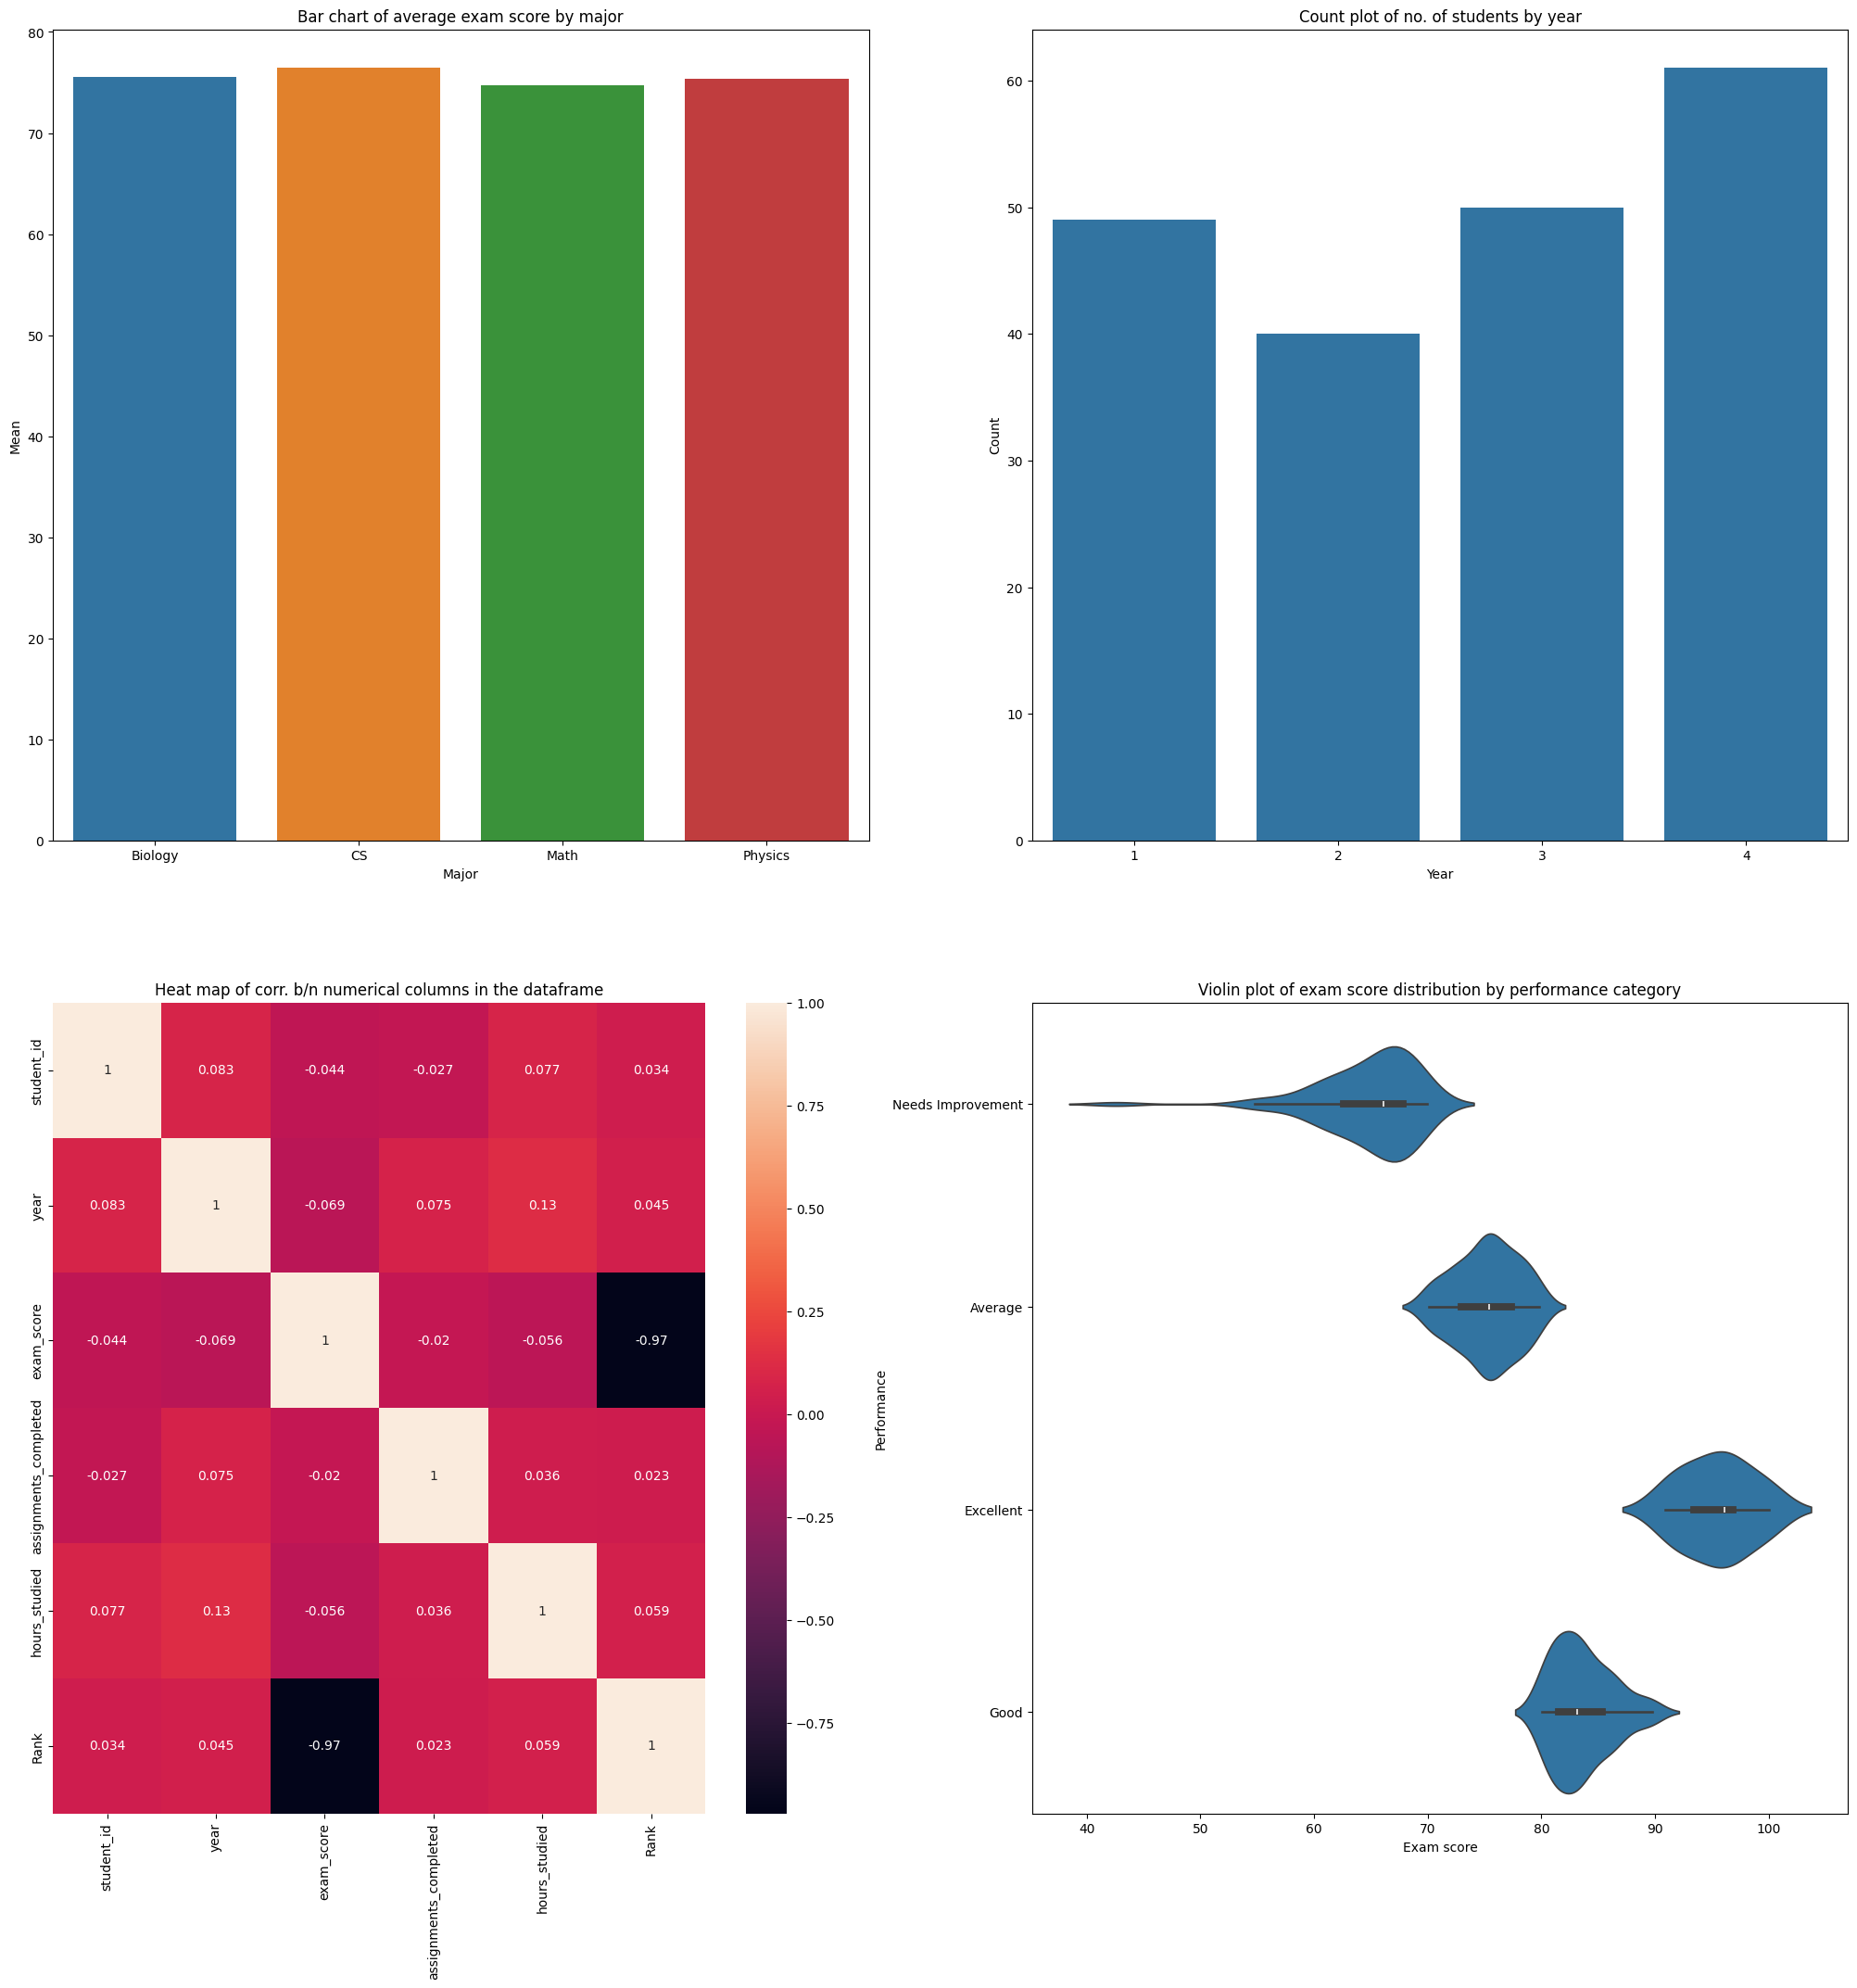

In [65]:
# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
# TODO: Adjust layout, add titles, and ensure readability

fig2, plots2 = plt.subplots(2, 2, figsize=(25, 25))

sns.barplot(avg_score_by_major, x='major', y='mean', ax=plots2[0, 0], hue='major')
plots2[0, 0].set_title('Bar chart of average exam score by major')
plots2[0, 0].set_xlabel('Major')
plots2[0, 0].set_ylabel('Mean')

sns.countplot(df, x='year', ax=plots2[0, 1])
plots2[0, 1].set_title('Count plot of no. of students by year')
plots2[0, 1].set_xlabel('Year')
plots2[0, 1].set_ylabel('Count')


hm = df.corr(numeric_only=True)
sns.heatmap(hm, ax=plots2[1, 0], annot=True)
plots2[1, 0].set_title('Heat map of corr. b/n numerical columns in the dataframe')

sns.violinplot(df, x='exam_score', y='Performance', ax=plots2[1, 1])
plots2[1, 1].set_title('Violin plot of exam score distribution by performance category')
plots2[1, 1].set_xlabel('Exam score')
plots2[1, 1].set_ylabel('Performance')

